# Analysis Script for Inverted Polarity Test (aka Dark Mode)


https://osf.io/mkq84/wiki/home/

### Imports 

In [1]:
%load_ext autoreload
%autoreload 2

In [42]:
import src.json_parsing as parse
from src.analysis import analysis_rates, analysis_position, trial_by_trial_analysis, landing_position_analysis, response_density_analysis
from src.helper_funcs import scramble_columns_piecewise
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Set paths

In [3]:
study_name = 'target_polarity'
study_type = 'remote'
data_path = f'../../../data/{study_type}/data_{study_name}'
results_path = f'../../../results/{study_type}/results_{study_name}'

### Parse Data

#### Define Parameters

In [45]:
# file paths
raw_input_path = f'{data_path}/full_remote_data.txt' # here we put the exported data file from jatos 
clean_output_path = f'{data_path}/preprocessed/clean_remote_data.csv' # here we put the path where we want to save the output data 
pix2deg_output_path = f'{data_path}/preprocessed/px2deg.csv' # here we put the data path where we want to save the pixel to dva transformation
test_path_clean_data  = f'{data_path}/test_files/clean_data_test.csv' # this is a test file we create manually by saving the first version of the analysis testing for validity

#extra_session_input_path = f'{data_path}/incomplete_data/incomplete_data.txt' # here we put the path where we safe incomplete data files
incomplete_worker_list   = ['90314', '90317', 
                            '90323', '90325', '90327']
incomplete_session_paths = [f'{data_path}/incomplete_data/comp-result_{worker}/files/trialData.json' for worker in incomplete_worker_list]


# data fragments to be filtered
filter_dict = {'component': 'Trials_Serial', 'test_part': 'trial'}
screen_parse_filter = {'component': 'Calibrate_Screen', 'trial_type': 'virtual-chinrest'} 

# define the number of desired entries in cells with lists
desired_length_dict = {'flashOnTime': 1,
                       'flashOffTime': 1,
                       'flashTime': 1,
                       'scheduled_change_onset': 1,
                       'touchOn': 6, 
                       'touchOff': 6,
                       'touchX': 6, 
                       'touchY': 6,
                       'choiceOrder': 6, 
                       'position_x': 6, 
                       'position_y': 6, 
                       'shifted_position_x': 6,
                       'shifted_position_y': 6}

set_dtype_dict = {'position_x': float,
                  'position_y': float,
                  'shifted_position_x': float,
                  'shifted_position_y': float,
                  'touchX': float,
                  'touchY': float,
                  'windowWidth': float,
                  'windowHeight': float,
                  'startTime': float,
                  'endTime': float,
                  'flashOnTime': float,
                  'flashOffTime': float,
                  'touchOn': float,
                  'touchOff': float,
                  'scheduled_change_onset': float,
                  'flash_duration': float,
                  'change_onset': float,
                  'trial_duration': float,
                  'choiceOrder': int,
                  'touchOn_relative': float,
                  'touchOff_relative': float}

# columns with lists as entries that need to be expanded
explode_lists = [['flashOnTime', 'flashOffTime', 'flashTime', 'scheduled_change_onset'],
                 ['touchOn', 'touchOff', 'touchX', 'touchY', 'choiceOrder', 'position_x', 'position_y', 'shifted_position_x', 'shifted_position_y']]

# define column names
set_time_cols = ['touchOn', 'touchOff']
relative_to_cols = ['startTime', 'flashOnTime']
remove_false_cols = ['success']
session_code_col = 'prolific_id'
pix2deg_col = 'px2deg'


# column names and keys to be removed from the experiment
# '612cfb6a63e838d72bbde6bc' is the researcher
# '616d67ccb4427923ca7a463d' participated only in the first session

outlier_dict = {'prolific_id': ['612cfb6a63e838d72bbde6bc', '616d67ccb4427923ca7a463d', 
                                '617065ce3f5273f5c92ef383', '60ddfb3db6a71ad9ba75e387']} # here we define participants that need to be removed from the study

### Run Parsing

In [46]:
trial_data = parse.format_and_save_data_multiple_participants(raw_input_path, clean_output_path, 
                                                              filter_dict=filter_dict, 
                                                              length_dict=desired_length_dict, 
                                                              explode_lists=explode_lists,
                                                              set_time_cols = set_time_cols,
                                                              relative_to_cols = relative_to_cols,
                                                              remove_false_cols = remove_false_cols,
                                                              outlier_dict = outlier_dict,
                                                              #extra_session_path = extra_session_input_path,
                                                              incomplete_session_paths = incomplete_session_paths,
                                                              format_dict = set_dtype_dict,
                                                              force_save_new = True)

pix2deg_dict =  parse.parse_screen_information(raw_input_path, 
                                               pix2deg_output_path, 
                                               screen_parse_filter, 
                                               outlier_dict, 
                                               session_code_col, 
                                               pix2deg_col)

### Test
If this test throws an error, then the generated "trial data" file does not match the previously created and approved data file.

You can continue running this notebook nevertheless. If you want to exchange the test file for the current file you need to do so manually after inspecting the file and the results carefully.

In [8]:
parse.test_file_equality(clean_output_path, test_path_clean_data)

### Look at Data

In [47]:
trial_data.head()

,success,trial_type,trial_index,time_elapsed,internal_node_id,subject,prolific_id,study_id,session_id,session_number,...,windowWidth,windowHeight,userInfo,platform,flashTime,trialID,stimJumped,flashShown,touchOn_relative,touchOff_relative
1,1.0,canvas-mi-serial,4,14638,0.0-2.0-0.1-0.1,24804,6043f909d14273455e5e7436,64ca4f23297059a92ea703d3,64d65eeb9a0a91a2b992d02c,2,...,815.0,393.0,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Linux armv81,511.218811,29.0,0.0,1.0,-521.637,-472.837
1,1.0,canvas-mi-serial,4,14638,0.0-2.0-0.1-0.1,24804,6043f909d14273455e5e7436,64ca4f23297059a92ea703d3,64d65eeb9a0a91a2b992d02c,2,...,815.0,393.0,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Linux armv81,511.218811,29.0,0.0,1.0,-331.137,-272.637
1,1.0,canvas-mi-serial,4,14638,0.0-2.0-0.1-0.1,24804,6043f909d14273455e5e7436,64ca4f23297059a92ea703d3,64d65eeb9a0a91a2b992d02c,2,...,815.0,393.0,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Linux armv81,511.218811,29.0,0.0,1.0,-104.837,-38.937
1,1.0,canvas-mi-serial,4,14638,0.0-2.0-0.1-0.1,24804,6043f909d14273455e5e7436,64ca4f23297059a92ea703d3,64d65eeb9a0a91a2b992d02c,2,...,815.0,393.0,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Linux armv81,511.218811,29.0,0.0,1.0,162.063,244.263
1,1.0,canvas-mi-serial,4,14638,0.0-2.0-0.1-0.1,24804,6043f909d14273455e5e7436,64ca4f23297059a92ea703d3,64d65eeb9a0a91a2b992d02c,2,...,815.0,393.0,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Linux armv81,511.218811,29.0,0.0,1.0,462.163,527.763


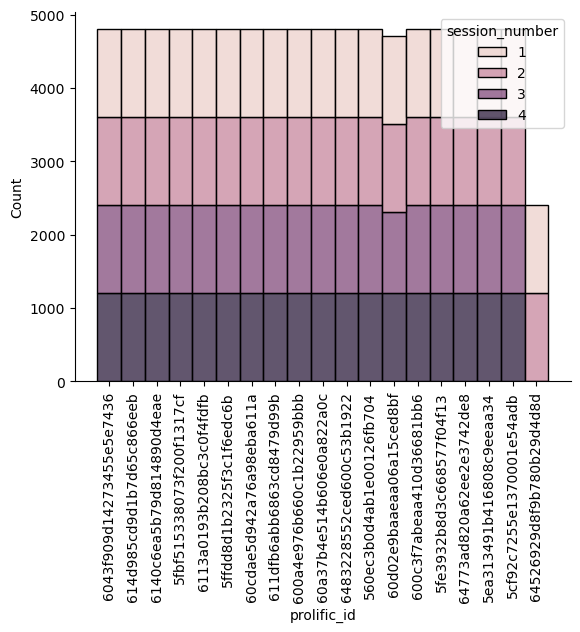

In [49]:
sns.histplot(data = trial_data,
             x = 'prolific_id',
             hue = 'session_number',
            multiple = 'stack')
plt.xticks(rotation = 90);

### Rate Analysis

#### Parameter Definition

In [27]:
# data file paths
movement_rate_metrics_path = f'{results_path}/movement_rate_metrics.csv' # here we put the path name for the rate metrics
movement_rate_figure_path = f'{results_path}/movement_rate_figure.png' # here we put the path name for the rate metrics
movement_rate_test_path  = f'{data_path}/test_files/movement_rate_test.csv' # this is a test file we create manually by saving the first version of the analysis testing for validity

# define the conditions
conditions_rates = {
    'flash_jump': {'flashShown': 1,
                  'stimJumped': 1},
    'flash_no_jump': {'flashShown': 1,
                  'stimJumped': 0},
    'no_flash_jump': {'flashShown': 0,
                  'stimJumped': 1},
    'no_flash_no_jump': {'flashShown': 0,
                  'stimJumped': 0},
}

# define color scheme for plots
color_rates = {
    'flash_jump': '#921120',
    'flash_no_jump': '#32828F',
    'no_flash_jump': '#F49CBB',
    'no_flash_no_jump': '#8BDAE4',
}


# set parameters for our analysis
rate_analysis_parameters = {'window_start': -700,
                            'window_end': 1500,
                            'search_start': 0,
                            'search_end': 700,
                            'baseline_start': -100,
                            'baseline_end': 0}

# define column names for the analysis
move_offset_col = 'touchOn_relative' # touchOn marks the time participants tapped on the screen. This happens at the END of a movement
move_onset_col = 'touchOff_relative' # touchOff is the time participants lifted their finder from the screen. This is the ONSET of a movement
participant_col = 'prolific_id'
touch_order_col = 'choiceOrder'

# ANOVA - define variables 
# We'll run one ANOVA per DV, with all IVs as input
dependent_variables = ['magnitude', 'latency']
independent_variables = ['flash_shown', 'stim_jumped']

#### Run Analysis

Results from ANOVA with 
DEPENDENT variable: MAGNITUDE; 
INDEPENDENT variables: ['FLASH_SHOWN', 'STIM_JUMPED'], 
GROUPED by: PROLIFIC_ID


                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
flash_shown              0.0263 1.0000 18.0000 0.8729
stim_jumped             54.4308 1.0000 18.0000 0.0000
flash_shown:stim_jumped  4.6201 1.0000 18.0000 0.0454

Results from ANOVA with 
DEPENDENT variable: LATENCY; 
INDEPENDENT variables: ['FLASH_SHOWN', 'STIM_JUMPED'], 
GROUPED by: PROLIFIC_ID


                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
flash_shown              0.0181 1.0000 18.0000 0.8944
stim_jumped              2.0012 1.0000 18.0000 0.1742
flash_shown:stim_jumped  0.0456 1.0000 18.0000 0.8333



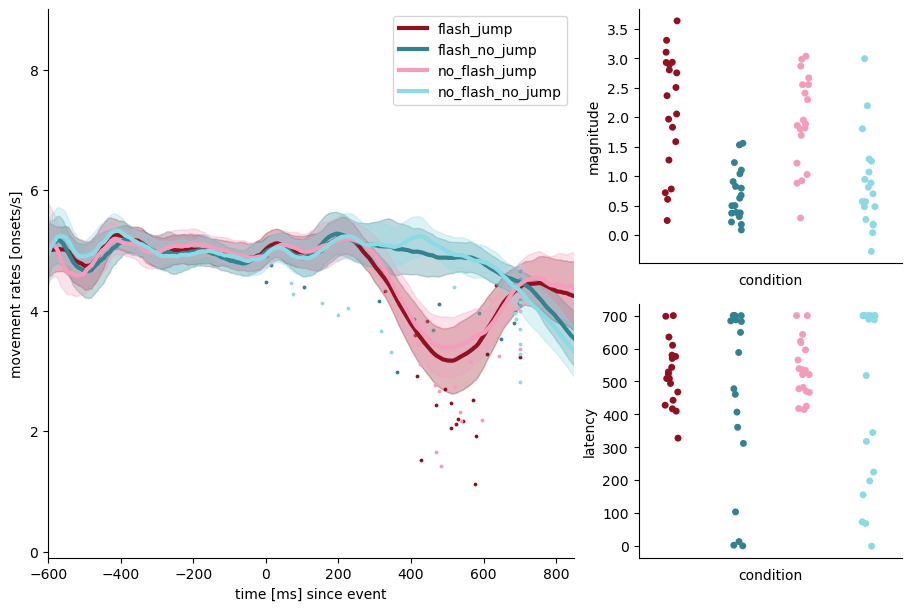

In [28]:
analysis_rates(trial_data,
               move_offset_col,
               move_onset_col,
               participant_col,
               rate_analysis_parameters,
               touch_order_col,
               conditions_rates,
               color_rates,
               movement_rate_metrics_path,
               movement_rate_figure_path,
               dependent_variables,
               independent_variables)

#### Test if the metrics changed

In [29]:
parse.test_file_equality(movement_rate_metrics_path, movement_rate_test_path)

### Obsersation in plot above:

*Type here* 

### Trial-by-Trial Analysis

- statistical comparison to baseline
- add distribution of trial numbers

In [30]:
figure_path = f'{results_path}/flight_rest_times_figure.png' # Here we put the name of the figure where we want to save the movement duration analysis


conditions_dict = {
    'flash+ jump+': {'flashShown': 1,
                  'stimJumped': 1},
    'flash+ jump-': {'flashShown': 1,
                  'stimJumped': 0},
    'flash- jump+': {'flashShown': 0,
                  'stimJumped': 1},
    }


baseline_condition_dict = {'flashShown': 0,
                  'stimJumped': 0}

touch_onset_col = 'touchOn'
touch_offset_col = 'touchOff'
touch_relative_col = 'touchOff_relative'

plot_columns = {'rest': 'rest_times', 'flight': 'flight_times'}
colors = {'full cycle': '#394F49', 
          'rest': '#EFDD8D', 
          'flight': '#65743A'}
smooth_window = 40

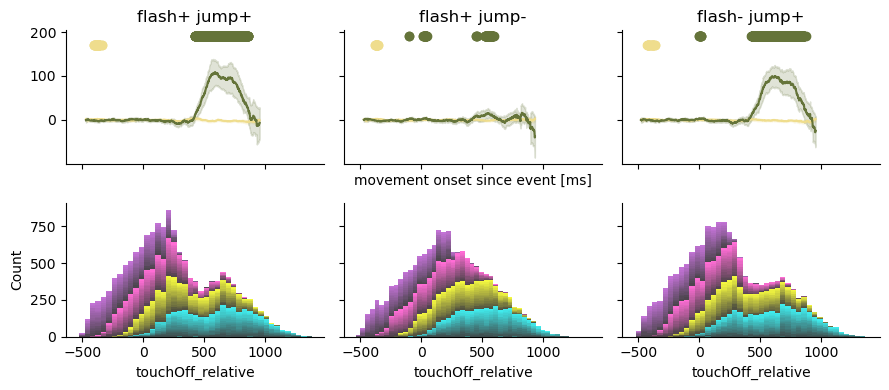

In [31]:
time, participant_timings = trial_by_trial_analysis(trial_data, 
                                                    touch_relative_col, 
                                                    plot_columns, 
                                                    conditions_dict, 
                                                    baseline_condition_dict, 
                                                    colors, 
                                                    participant_col, 
                                                    touch_onset_col, 
                                                    touch_offset_col, 
                                                    smooth_window, 
                                                    figure_path)

### Response Position Adjustment Analysis
#### Parameter Definition

In [32]:
# data file paths
position_adjustment_metrics_path = f'{results_path}/position_adjustment_metrics.csv' # Here we put the file name for the output of our reponse position analysis
position_adjustment_test_path = f'{data_path}/test_files/position_adjustment_test.csv' # Here we put the name of the test file


conditions_position = {
    'flash_jump': {'flashShown': 1,
                  'stimJumped': 1},
    'no_flash_jump': {'flashShown': 0,
                  'stimJumped': 1},
}

condition_shift_color_dict = {
    'flash_jump': 'black',
    'no_flash_jump': 'green',
}


window_width_col = 'windowWidth'
window_height_col = 'windowHeight'
touch_x_col = 'touchX'
touch_y_col = 'touchY'
target_x_col = 'shifted_position_x'
target_y_col = 'shifted_position_y'
time_col_name = 'touchOn_relative'
independent_variables_shift = {'flash_shown': [0, 1]}
dependent_variables_shift = ['L', 'b', 'x0', 'k']

set_dtype_dict = {'touchOn_relative': float,
                  'touchOff_relative': float}

participant_col = 'prolific_id'

params = {
    'smooth': 200,
    'start_smooth': -700,
    'end_smooth': 1500,
}

#### Analysis

/opt/anaconda3/envs/mi_env/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Results from paired T-Test with 
DEPENDENT variable: L ; 
INDEPENDENT variables: flash_shown at levels [0, 1]
Ttest_relResult(statistic=-1.1275039913382392, pvalue=0.2743354679836013) 


Results from paired T-Test with 
DEPENDENT variable: b ; 
INDEPENDENT variables: flash_shown at levels [0, 1]
Ttest_relResult(statistic=1.3212625512011442, pvalue=0.20296398243859715) 


Results from paired T-Test with 
DEPENDENT variable: x0 ; 
INDEPENDENT variables: flash_shown at levels [0, 1]
Ttest_relResult(statistic=-0.4505288430514461, pvalue=0.6583742433702895) 


Results from paired T-Test with 
DEPENDENT variable: k ; 
INDEPENDENT variables: flash_shown at levels [0, 1]
Ttest_relResult(statistic=-1.283148369316748, pvalue=0.21571575317271227) 




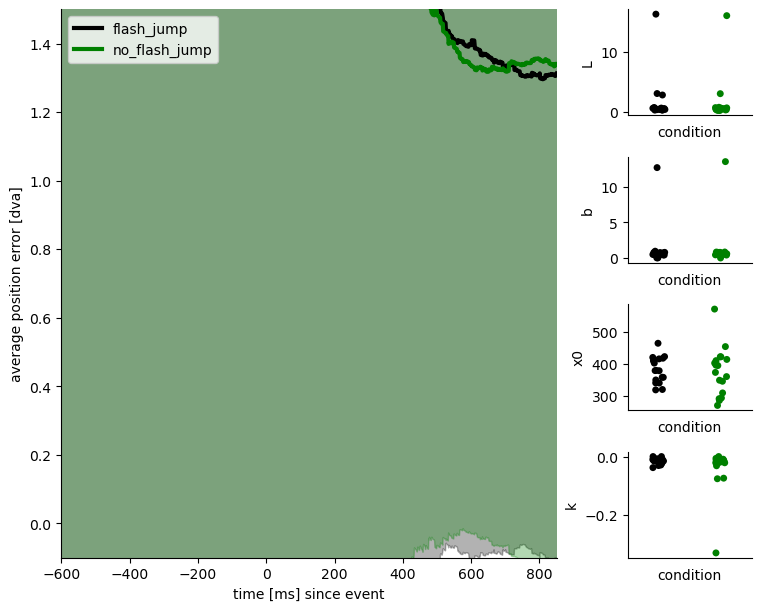

In [50]:
jump_only_data = analysis_position(trial_data.copy(deep = True), 
                  touch_x_col, 
                  touch_y_col, 
                  target_x_col, 
                  target_y_col, 
                  window_width_col, 
                  window_height_col, 
                  session_code_col, 
                  pix2deg_dict, 
                  participant_col, 
                  conditions_position, 
                  condition_shift_color_dict,
                  time_col_name, 
                  params,
                  dependent_variables_shift,
                  independent_variables_shift,
                  position_adjustment_metrics_path,
                  set_dtype_dict)

#### Test

In [34]:
parse.test_file_equality(position_adjustment_metrics_path, position_adjustment_test_path)

### Response Position - Mixed or Distinct? 

In [35]:
# Parameters

x_touch = 'touchX_relative'
y_touch = 'touchY_relative'
x_dot_first = 'position_x'
y_dot_first = 'position_y'
x_dot_second = 'shifted_position_x'
y_dot_second = 'shifted_position_y'
onset_column = 'touchOn_relative'
offset_column = 'touchOff_relative'
order_column = 'choiceOrder'

parameters = {'window_start': -700,
              'window_end': 1500}

participant_col = 'prolific_id'

condition_color_dict = {
        'distance_new_dva': '#D6E3F8',
        'distance_old_dva':'#E4BB97',
        'distance_middle_dva': '#584B53'
    }

response_to_figure_path = f'{results_path}/response_to_position_figure.png' # Here we put the name of the figure where we want to save the movement duration analysis

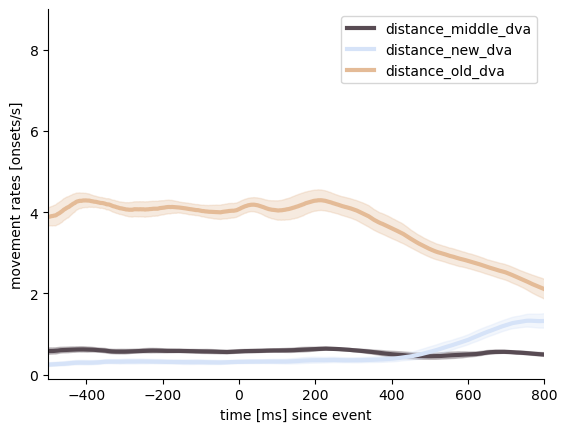

In [36]:
landing_position_analysis(jump_only_data, 
                          x_touch, y_touch, 
                          x_dot_first, y_dot_first, 
                          x_dot_second, y_dot_second, 
                          pix2deg_dict,
                          parameters, 
                          onset_column, 
                          offset_column, 
                          order_column, 
                          participant_col, 
                          condition_color_dict,
                          response_to_figure_path)      

In [39]:
conditions_dictionary = {'jump': {'stimJumped': 1},
                         'no_jump': {'stimJumped': 0}}

window_center_col = 'window_center'
touch_col = 'touch'
point_col = 'shifted_position'
origin_col = 'position'
dimensions = ['x', 'y']
rotation_degrees = 180
align_position_cols = ['shifted_position', 'centered_touch', 'position']
participant_col = 'prolific_id'
heatmap_params = {
    'n_col': 42,
    'n_row': 20,
    'x_min': -700,
    'x_max': 1400,
    'y_min': -1,
    'y_max': 2
}

ci = 0.96
time_col = 'touchOff_relative'

window_width_col = 'windowWidth'
window_height_col = 'windowHeight'
tap_order_col = 'choiceOrder'
scrambled_col = 'scrambled_position'

# some data transforms
trial_data[f'{window_center_col}_x'] = trial_data[window_width_col]/2
trial_data[f'{window_center_col}_y'] = trial_data[window_height_col]/2

trial_data[f'{touch_col}_x'] = trial_data['touchX']
trial_data[f'{touch_col}_y'] = trial_data['touchY']

# create scrambled comparison for no_jump condition
scramble_data = scramble_columns_piecewise(trial_data, f'{point_col}_x', tap_order_col, f'{scrambled_col}_x', 'subject')
scramble_data = scramble_columns_piecewise(scramble_data, f'{point_col}_y', tap_order_col, f'{scrambled_col}_y', 'subject')
test_data = trial_data.copy(deep = True)
test_data.loc[test_data.stimJumped == 0, f'{point_col}_x'] = scramble_data[scramble_data.stimJumped == 0][f'{scrambled_col}_x'].values
test_data.loc[test_data.stimJumped == 0, f'{point_col}_y'] = scramble_data[scramble_data.stimJumped == 0][f'{scrambled_col}_y'].values

/opt/anaconda3/envs/mi_env/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2343: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/opt/anaconda3/envs/mi_env/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2344: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


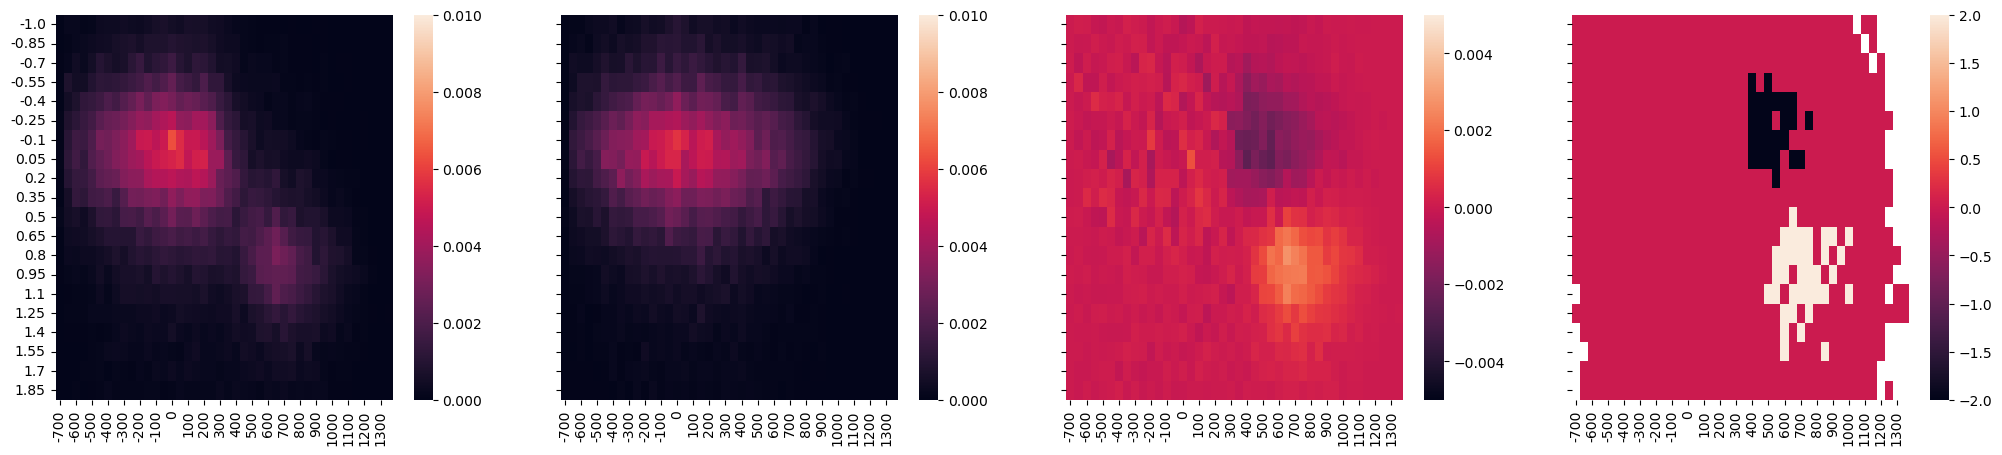

In [43]:
heatmap_dictionary = response_density_analysis(test_data, conditions_dictionary, 
                                       window_center_col, touch_col, 
                                       point_col, origin_col, 
                                       dimensions, rotation_degrees,
                                       align_position_cols, participant_col, 
                                       heatmap_params, time_col, ci)